# $$ \textbf{Sinais e Sistemas Dinâmicos}$$

## Sinais e Sistemas - Prova I

### Gabarito



In [42]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import * 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

**1. Questão** Um sistema $S$ em tempo contínuo é dado por
$$
y(t)=0,5 \int_{-\infty}^{\infty} x(\tau)[\delta(t-\tau)+\delta(t+\tau)] d \tau
$$

Lembre-se que $\delta(t)$ representa a função delta de Dirac.

(a) Explique o que este sistema faz.

(b) O sistema é estável BIBO? (Justifique).

(c) O sistema é linear? (Justifique).

(d) Quais as saídas para $x(t) = cos(t)$ e para $x_T(t) = cos(t - \pi/2)?$

(f) O sistema é invariante no tempo?  (Justifique).</font>


**Solução:**

(a) Explique o que este sistema faz.

A operação do sistema pode ser reescrita como $y(t)=0,5(x(t)+ x(-t))$. Assim, **este sistema extrai a parte par do sinal de entrada**.


(b) Se $|x(t)| \leq M_x<\infty$, então $|y(t)|=|0,5(x(t)+x(-t))| \leq 0,5(|x(t)|+|x(-t)|) \leq M_x<\infty$. Ou seja, entradas limitadas sempre produzem saídas limitadas e **o sistema é BIBO estável**.


(c) Sejam $y_1(t)=0,5 \left(x_1(t)+x_1(-t)\right)$ e $y_2(t)=0,5 \left(x_2(t)+x_2(-t)\right)$. 

Aplicar $a x_1(t)+b x_2(t)$ ao sistema produz 

$$
\begin{aligned}
y(t) &= 0,5\left(a x_1(t)+b x_2(t)+a x_1(-t)+ b x_2(-t)\right)\\
&=0,5 a\left(x_1(t)+x_1(-t)\right)+0,5 b\left(x_2(t)+x_2(-t)\right)\\
&=a y_1(t)+b y_2(t)
\end{aligned}
$$ 

e, portanto, **o sistema é linear**.

(d) Como o sistema extrai a parte par do sinal de entrada, temos que:

$$
S[cos(t)] = cos(t)
$$
e 
$$
S[cos(t - \pi/2)] = S[sin(t)] = 0.
$$

(e) considere o sistema $T$ que atrasa o sinal de entrada por $\pi/2 \mathrm{~s}.$

Temos que
$$
S[T[cos(t)]] =  S[cos(t - \pi/2)] = S[sin(t)] = 0.
$$
Por outro lado, temos
$$
T[S[cos(t)]] =  T[cos(t)] = cos(t - \pi/2).
$$
Assim, como $S$ e $T$ não comutam, o sistema $S$ **não é invariante no tempo**.

**2.** Dado o sinal $x(t) $ representado pela figura abaixo, 

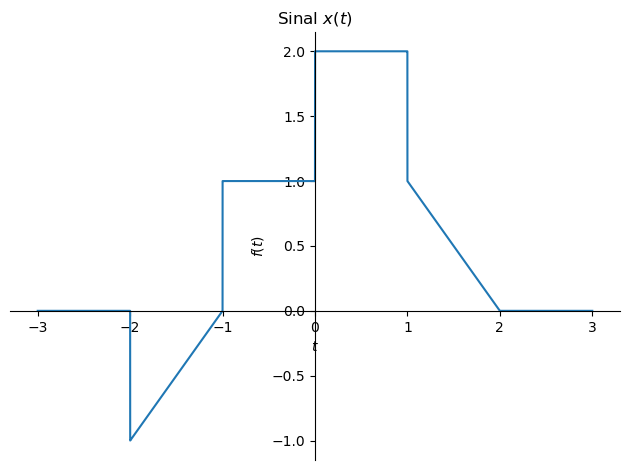

In [43]:
t = symbols('t')
x = sym.Piecewise((0, t<=-2), (t + 1, t<= -1), (1, t <=0), (2, t <=1), (-t + 2, t <=2), (0, True))
sym.plot(x, (t,-3,3), title='Sinal $x(t)$')

esboce o gráfico e determine a energia dos seguintes sinais

 a) $x\left(4-\frac{t}{2}\right)$;
 
 b) $[x(t)+x(-t)] u(t)$;
 
 c) $x(t)\left[\delta\left(t+\frac{3}{2}\right)-\delta\left(t-\frac{3}{2}\right)\right]$.

**Solução:**

(a)

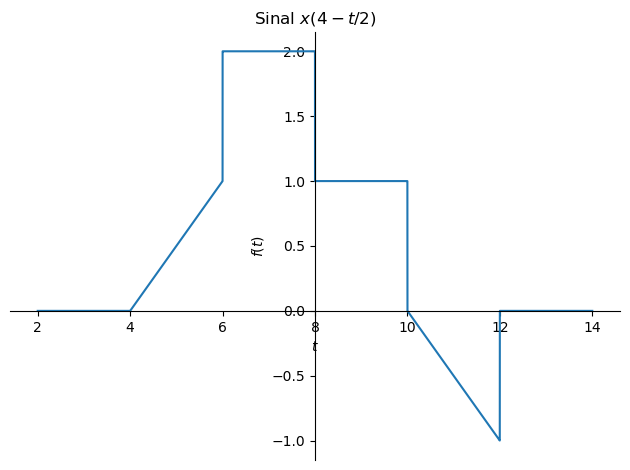

In [44]:
t = symbols('t')
xa = x.subs(t, 4 - t/2)

sym.plot(xa, (t,2,14), title='Sinal $x(4 - t/2)$')

In [79]:
Exa = integrate(xa**2,(t,-oo,oo))
display(Math('E_{x_a} = ' + latex(Exa))) 

<IPython.core.display.Math object>

(b)

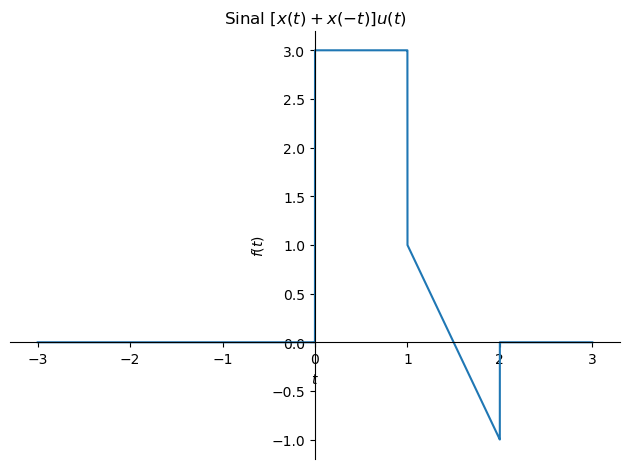

In [58]:
xb1 = x.subs(t, -t)
xb = xb1 + x
sym.plot(xb*Heaviside(t), (t,-3,3), title='Sinal $[x(t)+x(-t)] u(t)$')

In [59]:
Exb = integrate(xb**2,(t,0,oo))# integral a partir do 0 por conta do degrau unitário
display(Math('E_{x_b} = ' + latex(Exb)))

<IPython.core.display.Math object>

(c)

$$
\begin{aligned}
x(t)\left[\delta\left(t+\frac{3}{2}\right)-\delta\left(t-\frac{3}{2}\right)\right] & = x\left(\frac{-3}{2}\right)\delta\left(t+\frac{3}{2}\right) - x\left(\frac{3}{2}\right)\delta\left(t+\frac{3}{2}\right) \\
& = -0.5\delta\left(t+\frac{3}{2}\right) - 0.5\delta\left(t+\frac{3}{2}\right)
\end{aligned}
$$


Cuja representação é dada por
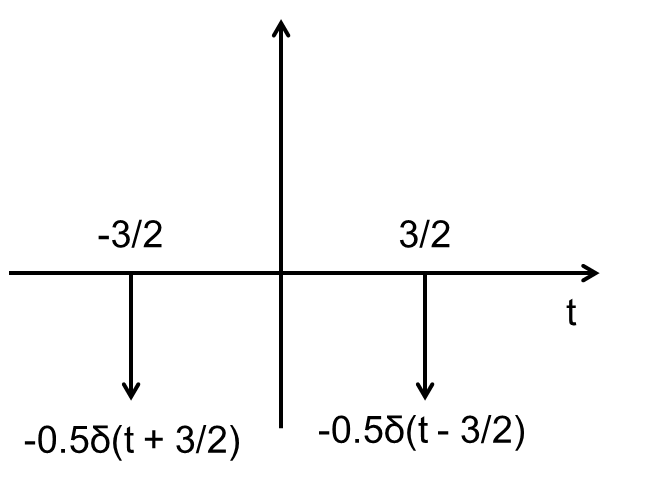

Embora o sympy dê como resultado

In [77]:
integrate(DiracDelta(t-3/2)**2,(t,-oo,oo))

DiracDelta(0)

salientamos que

$$
E_{\delta}=\int_{-\infty}^{\infty} \delta(t)^2 d t=\infty
$$

e que $\delta(t)^2$ não tem significado matemático.

**3.** Calcule as seguintes integrais:

(a) $\int_{-\infty}^{\infty} \delta(t+3) e^{-t} d t$;
    
(b) $\int_{-\infty}^{\infty} x(2-t) \delta(3-t) d t$;
    
(c) $\int_{-\infty}^{\infty} e^{(x-1)} \cos \left[\frac{\pi}{2}(x-5)\right] \delta(x-3) d x$.



**Solução:**

(a) $\int_{-\infty}^{\infty} \delta(t+3) e^{-t} d t = e^{3}\int_{-\infty}^{\infty} \delta(t+3)  d t = e^{3}$. 

Ou, alternativamente, 

In [80]:
t = symbols('t')
integrate(DiracDelta(t + 3)*exp(-t),(t,-oo,oo)).evalf()

20.0855369231877

(b)

In [31]:
x = symbols('x', cls=Function)
integrate(x(2 - t)*DiracDelta(3 - t),(t,-oo,oo))

x(-1)

(c)

In [81]:
x = symbols('x', cls=Function)
integrate(exp(t - 1)*cos((pi/2)*(t - 5))*DiracDelta(t - 3),(t,-oo,oo)).evalf()

-7.38905609893065

**4.** Um sistema pode ou não ser:

 1. Sem memória; 
 
 2. Invariante no tempo;
 
 3. Linear;
 
 4. Causal
 
 5. Bibo Estável.


Apresente exemplos de sistemas que satisfazem e de  que não satisfazem cada uma das propriedades acima. (Justifique!)

Como esta questão foi mais "aberta", não temos o seu gabarito.